# Retail Data Wrangling and Analytics

In [1]:
# Import modules 
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Load Data from PSQL into DataFrame

**Setup Docker Containers**

![](https://i.imgur.com/VQrBVBk.jpg)

```
#make sure you have both Jupyter and PSQL docker container running
docker ps

#Attach a bridge network to both containers so they can communicate with each other
docker network create jarvis-net
#this command works on running containers
docker network connect jarvis-net jarvis-jupyter
docker network connect jarvis-net jarvis-psql

#verify both containers are attached to the jarvis-net
docker network inspect trading-net

#Note: instead of using `localhost`, you should use container names as hostnames.
```

**Data Preperation**

- Use [pandas.read_sql](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_sql.html) api to load the PSQL retail table into a Pandas DataFrame

![](https://i.imgur.com/AmkAP63.jpg)

- Get familair with the transaction date with `df.head()`, `df.sample(10)`, `df.info()`, `df.describe()`, etc..



In [2]:
#install psql "driver"
!pip3 install psycopg2-binary

In [3]:
#Write your code in one or more cells (please remove this line from your notebook)

engine_string = ""
engine = ""
retail_df = pd.read_sql_table
retail_df.head()

AttributeError: 'function' object has no attribute 'head'

In [4]:
retail_df.info()
retail_df.describe()

AttributeError: 'function' object has no attribute 'info'

# Load CSV into Dataframe
Alternatively, the LGS IT team also dumped the transactional data into a [CSV file](https://raw.githubusercontent.com/jarviscanada/jarvis_data_eng_demo/feature/data/python_data_wrangling/data/online_retail_II.csv). However, the CSV header (column names) doesn't follow the snakecase or camelcase naming convention (e.g. `Customer ID` instead of `customer_id` or `CustomerID`). As a result, you will need to use Pandas to clean up the data before doing any analytics. In addition, unlike the PSQL scheme, CSV files do not have data types associated. Therefore, you will need to cast/convert certain columns into correct data types (e.g. DateTime, numbers, etc..)

**Data Preperation**

- Read the `data/online_retail_II.csv` file into a DataFrame
- Rename all columns to upper camelcase or snakecase
- Convert/cast all columns to the appropriate data types (e.g. datetime)

In [5]:
retail_df = pd.read_csv('data/online_retail_II.csv')
retail_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [7]:
# change column names
retail_df.rename(columns={'Customer ID': 'CustomerID'}, inplace=True)
retail_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [8]:
# Cast data types
retail_df = retail_df.astype(
    {
        'Invoice': 'string',
        'StockCode': 'string',
        'Description': 'string',
        'Quantity': 'int64',
        'CustomerID': 'Int64',
        'Country': 'string'
    }
)
retail_df['InvoiceDate'] = pd.to_datetime(retail_df['InvoiceDate'])
retail_df.dropna(inplace = True)

retail_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 824364 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      824364 non-null  string        
 1   StockCode    824364 non-null  string        
 2   Description  824364 non-null  string        
 3   Quantity     824364 non-null  int64         
 4   InvoiceDate  824364 non-null  datetime64[ns]
 5   Price        824364 non-null  float64       
 6   CustomerID   824364 non-null  Int64         
 7   Country      824364 non-null  string        
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(1), string(4)
memory usage: 57.4 MB


# Total Invoice Amount Distribution

---
**Please remove this insturction cell after you are done with coding**

1. Calculate the invoice amount. Note: an invoice consists of one or more items where each item is a row in the df. (hint: you need to `GROUP BY invoice`)
2. Draw the distribution of invoice amount with min, max, median, mod, and mean. However, you will notice many outlier data (e.g. invoices with large amounts). Sample hist and box charts:

![](https://i.imgur.com/N8hsbDa.jpg)

3. Draw the distribution for the first 85 quantiles of the invoice amount data with min, max, median, mod, and mean.


![](https://i.imgur.com/tJrH1qj.jpg)


---

In [9]:
# 1.Calculate the invoice amount.
retail_df['Amount'] = retail_df['Quantity']*retail_df['Price']

invoice_df = retail_df.groupby('Invoice')['Amount'].sum().reset_index()

Minimum:0.38
Mean:479.95
Median:305.25
Mode:15.00
Maximum:168469.60



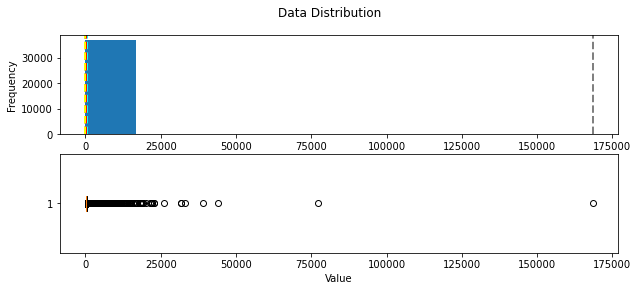

In [10]:
# 2.Draw the distribution of invoice amount with min, max, median, mod, and mean.
def show_distribution(var_data):
    # Get statistics
    min_val = var_data.min()
    max_val = var_data.max()
    mean_val = var_data.mean()
    med_val = var_data.median()
    mod_val = var_data.mode()[0]

    print('Minimum:{:.2f}\nMean:{:.2f}\nMedian:{:.2f}\nMode:{:.2f}\nMaximum:{:.2f}\n'.format(min_val,
                                                                                            mean_val,
                                                                                            med_val,
                                                                                            mod_val,
                                                                                            max_val))
    fig,ax = plt.subplots(2, 1, figsize = (10,4))
    
    # plot the histogram
    ax[0].hist(var_data)
    ax[0].set_ylabel('Frequency')
    
    ax[0].axvline(x=min_val, color='grey', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=mean_val, color = 'cyan', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=med_val, color = 'red', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=mod_val, color = 'yellow', linestyle='dashed', linewidth = 2)
    ax[0].axvline(x=max_val, color = 'gray', linestyle='dashed', linewidth = 2)

    # plot the boxplot
    ax[1].boxplot(var_data, vert=False)
    ax[1].set_xlabel('Value')
    
    fig.suptitle('Data Distribution')
    
    fig.show()

var_data = invoice_df[invoice_df['Amount']>0]['Amount']
show_distribution(var_data)


Minimum:0.38
Mean:272.75
Median:262.26
Mode:15.00
Maximum:676.54



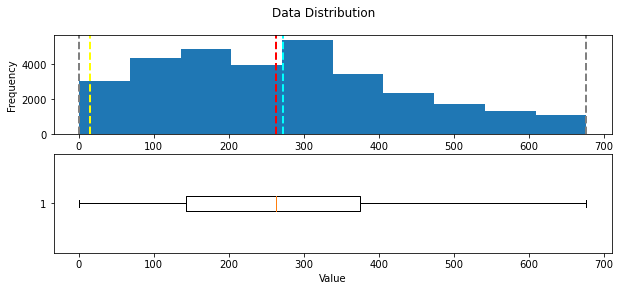

In [11]:
# 3.Draw the distribution for the first 85 quantiles of the invoice amount data with min, max, median, mod, and mean.
q85 = var_data.quantile(0.85)
remove_outliers = var_data[var_data < q85]

show_distribution(remove_outliers)

# Monthly Placed and Canceled Orders

---
**Please remove this insturction cell after you are done with coding**

- The attribute information (see the `project kick-off` section) contains useful information that helps you to identify canceled orders
- To simplify the problem, you can assume that there are two invoice numbers for each canceled order (one for the original invoice and one for the canceled invoice). Therefore, `# of placed orders = total # of orders - 2 * canceled order`. Furthermore, you can also assume the original invoice and canceled invoice are on always on the same day (this eliminate the case where the original invoice and canceled invoices are on different months)
- hints: you might want to create a new integer column with YYYYMM format. e.g. `2009-12-01 07:45:00 -> 200912` which allows easy GROUP BY.

**Sample Plot:**

![](https://i.imgur.com/tmLsPDf.jpg)

---

In [12]:
retail_df['YYYYMM'] = retail_df['InvoiceDate'].dt.strftime('%Y%m')
retail_df['IsCanceled'] = retail_df['Invoice'].str.startswith('C')
retail_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Amount,YYYYMM,IsCanceled
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,200912,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,200912,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,200912,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,200912,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,200912,False
...,...,...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60,201112,False
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60,201112,False
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60,201112,False
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France,14.85,201112,False


In [14]:
monthly_total = retail_df.groupby('YYYYMM')['Amount'].nunique()
monthly_canceled = retail_df[retail_df['IsCanceled']].groupby('YYYYMM')['Amount'].nunique()

df = pd.concat([monthly_total, monthly_canceled], axis=1)
df = df.reset_index()
df.columns = ['InvoiceYearMonth', 'Total', 'Cancellation']
df['Placement'] = df['Total'] - 2*df['Cancellation']

df

,InvoiceYearMonth,Total,Cancellation,Placement
0,200912,1228,256,716
1,201001,1143,219,705
2,201002,985,177,631
3,201003,1202,238,726
4,201004,1078,200,678
5,201005,1196,282,632
6,201006,1150,248,654
7,201007,1080,230,620
8,201008,1101,207,687
9,201009,1215,268,679


<AxesSubplot:xlabel='InvoiceYearMonth'>

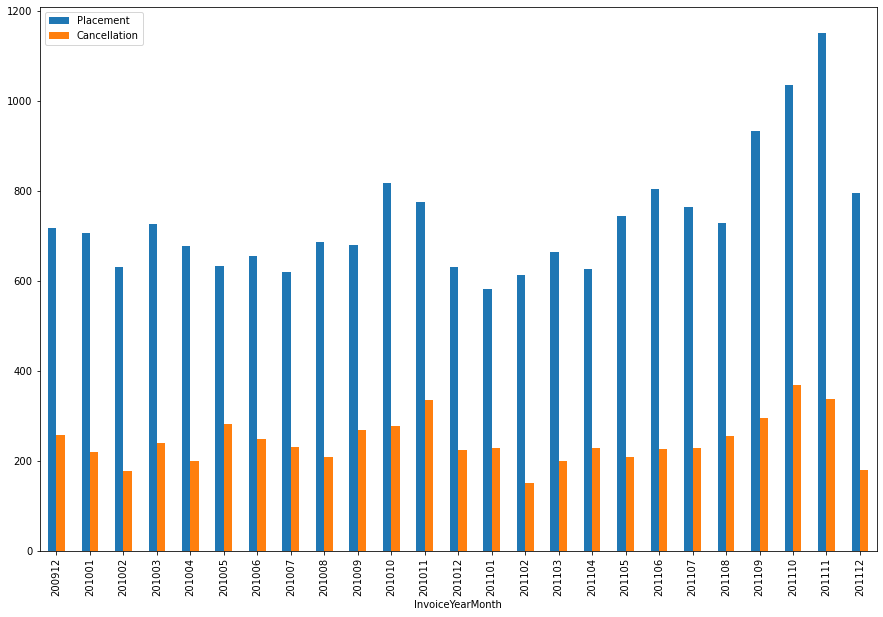

In [15]:
df.plot(x='InvoiceYearMonth', y=['Placement', 'Cancellation'], kind='bar', figsize=(15,10))

# Monthly Sales

---
**Please remove this insturction cell after you are done with coding**


- Calculate the monthly sales data
- Plot a chart to show monthly sales (e.g. x-asix=year_month, y-axis=sales_amount)

![](https://i.imgur.com/k1KOqKO.jpg)

---

Text(0, 0.5, 'Sales(Monthly)')

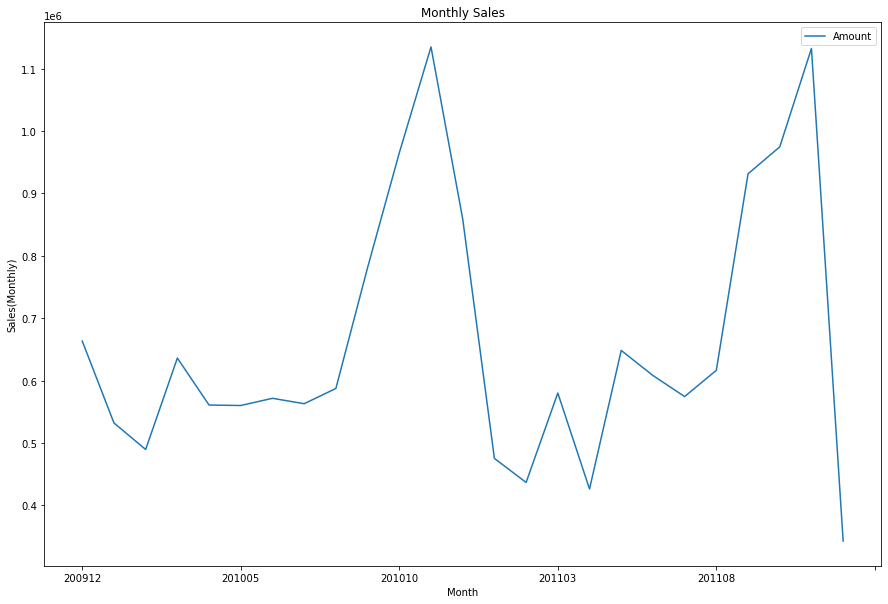

In [16]:
# Calculate the monthly sales data
monthly_sale_df = retail_df.groupby('YYYYMM')['Amount'].sum()
monthly_sale_df = monthly_sale_df.reset_index()

# plot the trend line chart
monthly_sale_df.plot(x='YYYYMM', y='Amount', kind='line', figsize=(15,10))

plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales(Monthly)')


# Monthly Sales Growth


---
**Please remove this insturction cell after you are done with coding**

- Calculate monthly sales percentage growth data
- Plot a chart to show the growth percentage

![](https://i.imgur.com/J3btp8j.jpg)

---

Text(0, 0.5, 'Growth %')

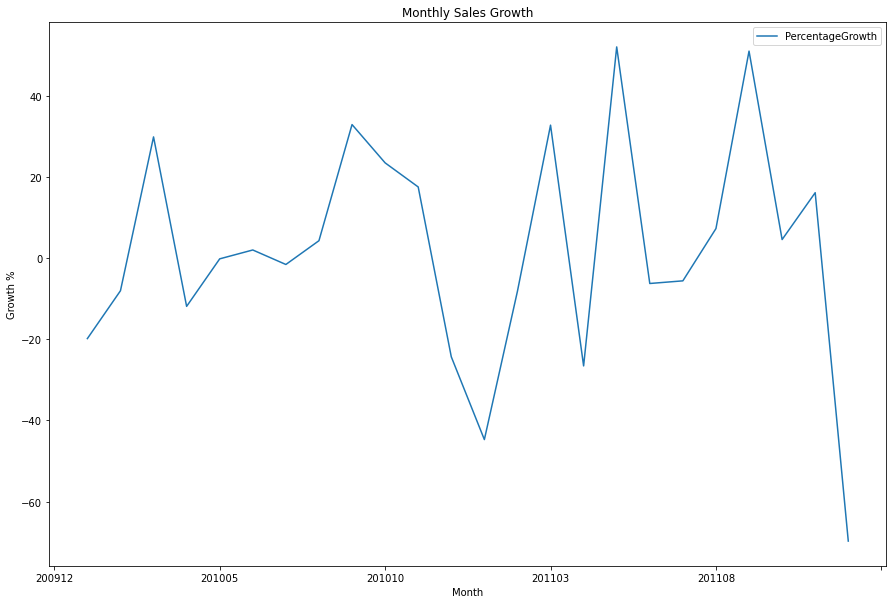

In [17]:
#Calculate monthly sales percentage growth data
monthly_sale_df = monthly_sale_df.sort_values('YYYYMM')
monthly_sale_df['PercentageGrowth'] = monthly_sale_df['Amount'].pct_change()*100

# plot the line chart
monthly_sale_df.plot(x='YYYYMM', y='PercentageGrowth', kind='line', figsize=(15,10))
plt.title('Monthly Sales Growth')
plt.xlabel('Month')
plt.ylabel('Growth %')


# Monthly Active Users

---
**Please remove this insturction cell after you are done with coding**

- Compute # of active users (e.g. unique `CusotomerID`) for each month
- Plot a bar chart

![](https://i.imgur.com/eFYp8VF.jpg)

---

Text(0, 0.5, '# of Active Users')

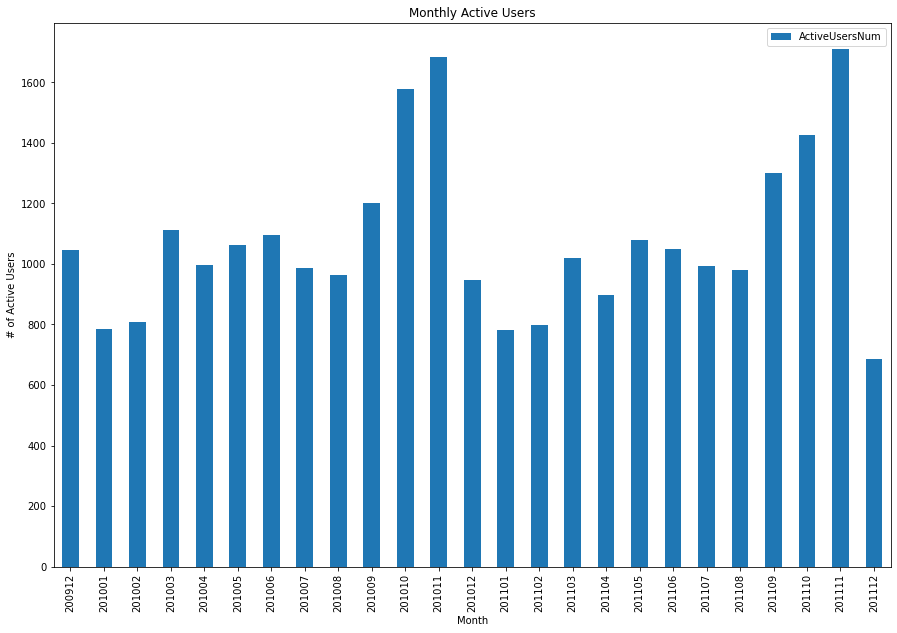

In [18]:
# Compute # of active users (e.g. unique CusotomerID) for each month
monthly_active_users_df = retail_df.groupby('YYYYMM')['CustomerID'].nunique()
monthly_active_users_df = monthly_active_users_df.reset_index()
monthly_active_users_df.columns = ['YYYYMM', 'ActiveUsersNum']

# PLot the bar chart
monthly_active_users_df.plot(x='YYYYMM', y='ActiveUsersNum', kind='bar', figsize=(15,10))
plt.title('Monthly Active Users')
plt.xlabel('Month')
plt.ylabel('# of Active Users')

# New and Existing Users



---
**Please remove this insturction cell after you are done with coding**

- Plot a diagram to show new and exiting user for each month.
- A user is identified as a new user when he/she makes the first purchase
- A user is identified as an existing user when he/she made purchases in the past
- hints:
  - find out the first purchase year-month for each user and then join this data with the transactional data to help you identified new/exiting users

![](https://i.imgur.com/nWjnrpr.jpg)

---

In [19]:
# create a new column for the first purchase month
retail_df['FirstPurchaseMonth'] = retail_df.groupby('CustomerID')['YYYYMM'].transform('min')

df = retail_df[["YYYYMM", "CustomerID", "FirstPurchaseMonth"]].drop_duplicates()

new_user_count_df = df[df['FirstPurchaseMonth'] == df['YYYYMM']].groupby('YYYYMM')['CustomerID'].nunique().reset_index()
new_user_count_df.columns = ['YYYYMM', 'NewNum']
ex_user_count_df = df[df['FirstPurchaseMonth'] < df['YYYYMM']].groupby('YYYYMM')['CustomerID'].nunique().reset_index()
ex_user_count_df.columns = ['YYYYMM', 'ExNum']

# Join the two dfs together
new_ex_df = new_user_count_df.merge(ex_user_count_df, on='YYYYMM', how='outer')

new_ex_df 

,YYYYMM,NewNum,ExNum
0,200912,1045,NaN
1,201001,394,392.0
2,201002,363,444.0
3,201003,436,675.0
4,201004,291,707.0
5,201005,254,808.0
6,201006,269,826.0
7,201007,183,805.0
8,201008,158,806.0
9,201009,242,960.0


<AxesSubplot:xlabel='YYYYMM'>

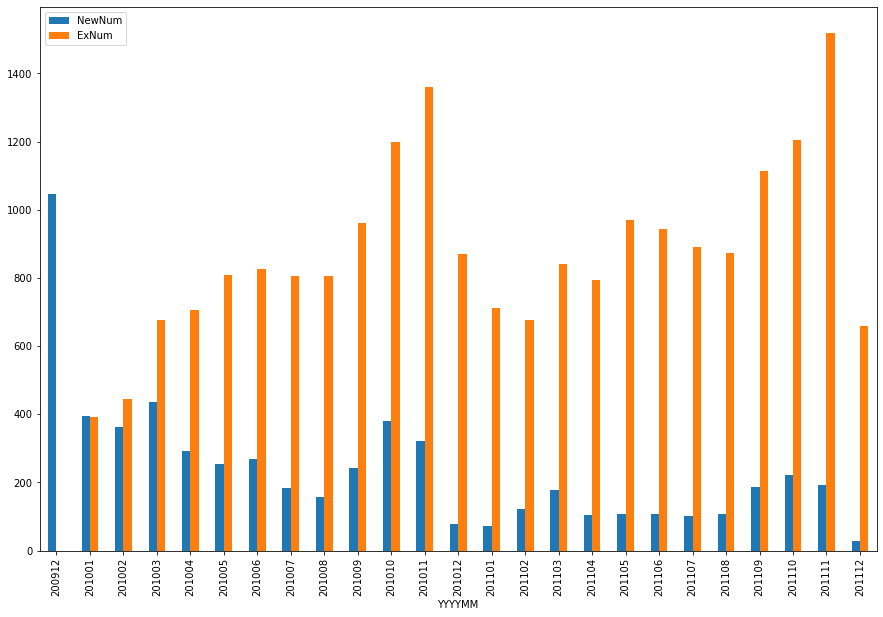

In [20]:
# Plot the bar chart
new_ex_df.plot(x='YYYYMM', y=['NewNum', 'ExNum'], kind='bar', figsize=(15,10))

## Finding RFM

RFM is a method used for analyzing customer value. It is commonly used in database marketing and direct marketing and has received particular attention in the retail and professional services industries. ([wikipedia](https://en.wikipedia.org/wiki/RFM_(market_research)))

Optional Reading: [Making Your Database Pay Off Using Recency Frequency and Monetary Analysis](http://www.dbmarketing.com/2010/03/making-your-database-pay-off-using-recency-frequency-and-monetary-analysis/)


RFM stands for three dimensions:

- Recency – How recently did the customer purchase?

- Frequency – How often do they purchase?

- Monetary Value – How much do they spend?

Note: To simplify the problem, let's keep all placed and canceled orders.


**Sample RFM table**

![](https://i.imgur.com/sXFIg6u.jpg)

In [21]:
retail_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Amount,YYYYMM,IsCanceled,FirstPurchaseMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,200912,False,200912
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,200912,False,200912
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,200912,False,200912
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,200912,False,200912
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,200912,False,200912
...,...,...,...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60,201112,False,201108
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60,201112,False,201108
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60,201112,False,201108
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France,14.85,201112,False,201108


In [23]:
today = pd.datetime(2012,1,1) 

rfm_df = retail_df.groupby('CustomerID').agg(
        {
            'InvoiceDate': lambda x: (today - x.max()).days,
            'Invoice': 'nunique',
            'Amount': 'sum'
            
        }
).reset_index()
rfm_df.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

rfm_df

<ipython-input-23-6181c1daf6e2>:1: FutureWarning: The pandas.datetime class is deprecated and will be removed from pandas in a future version. Import from datetime module instead.
  today = pd.datetime(2012,1,1)


,CustomerID,Recency,Frequency,Monetary
0,12346,347,17,-64.68
1,12347,24,8,5633.32
2,12348,97,5,2019.40
3,12349,40,5,4404.54
4,12350,332,1,334.40
...,...,...,...,...
5937,18283,25,22,2736.65
5938,18284,451,2,436.68
5939,18285,682,1,427.00
5940,18286,498,3,1188.43


# RFM Segmentation

---
**Please remove this insturction cell after you are done with coding**
RFM segmentation categorizes your customers into different segments, according to their interactions with your website, which will allow you to subsequently approach these groups in the most effective way. In this article, we will show you how to make an RFM segmentation based on an RFM score combining all three RFM parameters together and allowing you to divide your customers into 11 different segments. 

- [RFM Segmentation business cases](https://docs.exponea.com/docs/rfm-segmentation-business-use)

- [RFM Segmentation Guide](https://docs.exponea.com/docs/rfm-segmentation-business-use)

As you can see, computing RFM segmentation requires extensive domain knowledge in marketing which is out of the scope in this project. In practice, you will work with BA/DA to figure out how to compute RFM segments. To simplify this project, a [sample RFM segmentation Notebook](https://github.com/jarviscanada/jarvis_data_eng_demo/blob/feature/data/python_data_wrangling/ipynb/customer-segmentation-with-rfm-score.ipynb) is provided. You are responsible to understand everything from that Notebook and then integrate it into yours. 

- Download the [sample notebook](https://github.com/jarviscanada/jarvis_data_eng_demo/blob/feature/data/python_data_wrangling/ipynb/customer-segmentation-with-rfm-score.ipynb) and import to your Jupyter Notebook or VSCode
- Run the notebook and understand all cells
- Read the remark section at the end of the notebook. You will need this information when writing the README file
- Integrate the RFM segmentation calculation into your notebook

---

In [26]:
#RFM score values 
rfm_df['RecencyScore'] = pd.qcut(rfm_df['Recency'],5,labels=[5,4,3,2,1])
rfm_df['FrequencyScore'] = pd.qcut(rfm_df['Frequency'].rank(method="first"),5,labels=[1,2,3,4,5])
rfm_df['MonetaryScore'] = pd.qcut(rfm_df['Monetary'],5,labels=[1,2,3,4,5])

rfm_df

,CustomerID,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore
0,12346,347,17,-64.68,2,5,1
1,12347,24,8,5633.32,5,4,5
2,12348,97,5,2019.40,3,3,4
3,12349,40,5,4404.54,5,3,5
4,12350,332,1,334.40,2,1,2


In [29]:
#calculation of the RFM score
rfm_df["RFM_SCORE"] = rfm_df['RecencyScore'].astype(str) + rfm_df['FrequencyScore'].astype(str) + rfm_df['MonetaryScore'].astype(str)

rfm_df.head()

,CustomerID,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,RFM_SCORE
0,12346,347,17,-64.68,2,5,1,251
1,12347,24,8,5633.32,5,4,5,545
2,12348,97,5,2019.40,3,3,4,334
3,12349,40,5,4404.54,5,3,5,535
4,12350,332,1,334.40,2,1,2,212


In [31]:
rfm_df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,5942.0,15316.500000,1715.451981,12346.00,13831.2500,15316.50,16801.750,18287.00
Recency,5942.0,224.457085,211.881245,22.00,46.0000,117.50,403.000,760.00
Frequency,5942.0,7.552339,15.972262,1.00,2.0000,4.00,8.000,510.00
Monetary,5942.0,2801.799459,13973.922553,-25111.09,325.0975,843.97,2182.005,598215.22


In [32]:
#customers with RFM Score 555
rfm_df[rfm_df["RFM_SCORE"] == "555"].head()

,CustomerID,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,RFM_SCORE
13,12359,29,14,8714.89,5,5,5,555
16,12362,25,14,5284.58,5,5,5,555
49,12395,37,18,5046.92,5,5,5,555
71,12417,25,27,6708.21,5,5,5,555
87,12433,22,11,20428.86,5,5,5,555


In [33]:
#segmenting of customers according to RecencyScore and FrequencyScore values
seg_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At Risk',
    r'[1-2]5': 'Can\'t Lose',
    r'3[1-2]': 'About to Sleep',
    r'33': 'Need Attention',
    r'[3-4][4-5]': 'Loyal Customers',
    r'41': 'Promising',
    r'51': 'New Customers',
    r'[4-5][2-3]': 'Potential Loyalists',
    r'5[4-5]': 'Champions'
}

In [37]:
#creation of segment variable
rfm_df['Segment'] = rfm_df['RecencyScore'].astype(str) + rfm_df['FrequencyScore'].astype(str)
rfm_df['Segment'] = rfm_df['Segment'].replace(seg_map, regex=True)

rfm_df.head()

,CustomerID,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,RFM_SCORE,Segment
0,12346,347,17,-64.68,2,5,1,251,Can't Lose
1,12347,24,8,5633.32,5,4,5,545,Champions
2,12348,97,5,2019.40,3,3,4,334,Need Attention
3,12349,40,5,4404.54,5,3,5,535,Potential Loyalists
4,12350,332,1,334.40,2,1,2,212,Hibernating


In [38]:
rfm_df.groupby("Segment")[["Segment", "Recency","Frequency","Monetary"]].agg(["mean","count"])

Recency        Frequency            Monetary      
                           mean count       mean count          mean count
Segment                                                                   
About to Sleep       129.689474   380   1.460526   380    492.810900   380
At Risk              398.094415   752   4.672872   752   1157.449162   752
Can't Lose           343.305882    85  17.717647    85   5725.638494    85
Champions             29.512850   856  23.532710   856  10510.937634   856
Hibernating          487.237785  1535   1.336808  1535    340.030536  1535
Loyal Customers       89.149565  1150  11.941739  1150   3966.024762  1150
Need Attention       135.395604   273   3.673993   273   1099.877403   273
New Customers         31.814815    54   1.000000    54    362.463148    54
Potential Loyalists   46.674764   741   2.967611   741    899.359865   741
Promising             59.758621   116   1.000000   116    322.758966   116